In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/content/E-commerce data.csv')

# Basic exploration
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nFirst rows:")
df.head()

Shape: (10999, 12)

Columns: ['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']

Data types:
 ID                      int64
Warehouse_block        object
Mode_of_Shipment       object
Customer_care_calls     int64
Customer_rating         int64
Cost_of_the_Product     int64
Prior_purchases         int64
Product_importance     object
Gender                 object
Discount_offered        int64
Weight_in_gms           int64
Reached.on.Time_Y.N     int64
dtype: object

Missing values:
 ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

First rows:


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
# Statistical summary
print(df.describe())

                ID  Customer_care_calls  Customer_rating  Cost_of_the_Product  \
count  10999.00000         10999.000000     10999.000000         10999.000000   
mean    5500.00000             4.054459         2.990545           210.196836   
std     3175.28214             1.141490         1.413603            48.063272   
min        1.00000             2.000000         1.000000            96.000000   
25%     2750.50000             3.000000         2.000000           169.000000   
50%     5500.00000             4.000000         3.000000           214.000000   
75%     8249.50000             5.000000         4.000000           251.000000   
max    10999.00000             7.000000         5.000000           310.000000   

       Prior_purchases  Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
count     10999.000000      10999.000000   10999.000000         10999.000000  
mean          3.567597         13.373216    3634.016729             0.596691  
std           1.522860         16

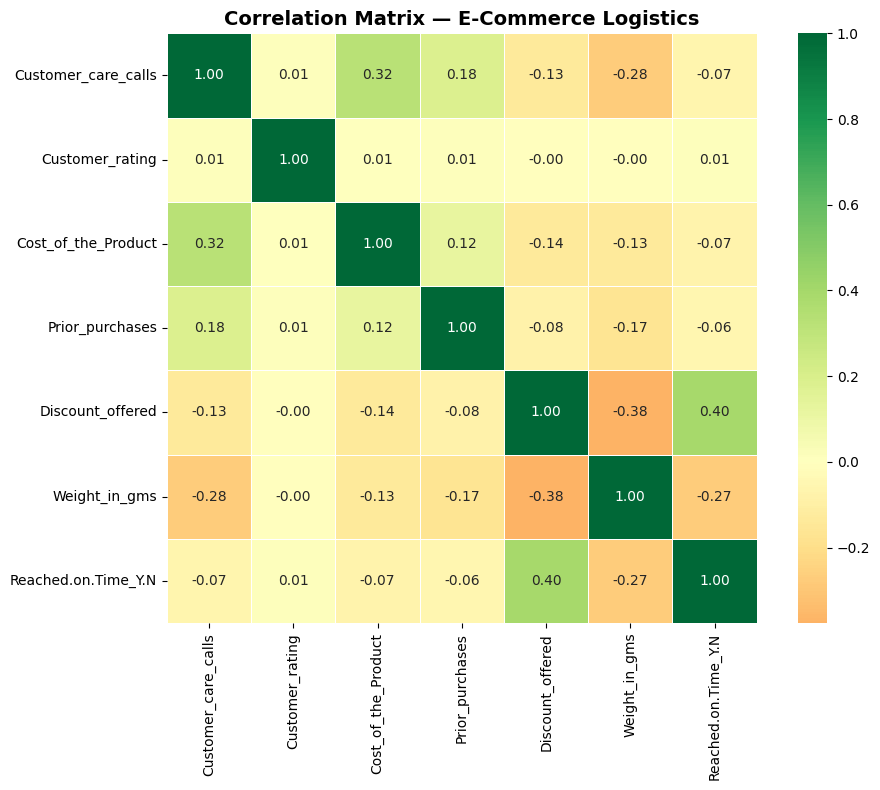

In [4]:
# Correlation matrix
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include='number').drop(columns=['ID'])
correlation = numeric_cols.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix — E-Commerce Logistics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

/tmp/ipykernel_2158/20939060.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_by_discount = df.groupby('discount_category')['Reached.on.Time_Y.N'].mean() * 100


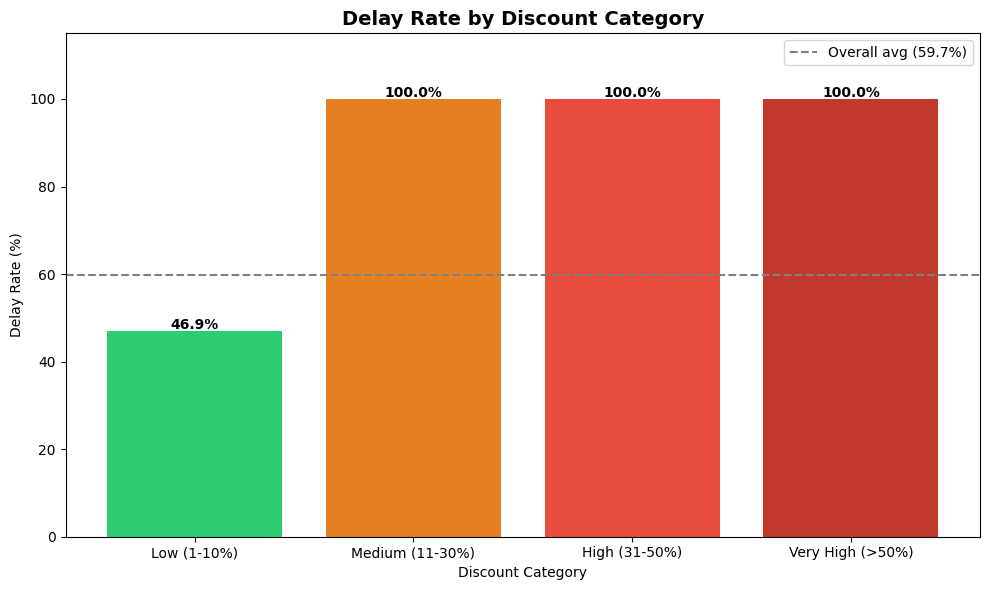

In [5]:
# Delay rate by discount category
df['discount_category'] = pd.cut(
    df['Discount_offered'],
    bins=[0, 10, 30, 50, 65],
    labels=['Low (1-10%)', 'Medium (11-30%)', 'High (31-50%)', 'Very High (>50%)']
)

delay_by_discount = df.groupby('discount_category')['Reached.on.Time_Y.N'].mean() * 100

plt.figure(figsize=(10, 6))
bars = plt.bar(
    delay_by_discount.index,
    delay_by_discount.values,
    color=['#2ecc71', '#e67e22', '#e74c3c', '#c0392b']
)

# Add value labels on bars
for bar, val in zip(bars, delay_by_discount.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.axhline(y=59.7, color='gray', linestyle='--', label='Overall avg (59.7%)')
plt.title('Delay Rate by Discount Category', fontsize=14, fontweight='bold')
plt.xlabel('Discount Category')
plt.ylabel('Delay Rate (%)')
plt.ylim(0, 115)
plt.legend()
plt.tight_layout()
plt.savefig('delay_by_discount.png', dpi=150)
plt.show()

/tmp/ipykernel_2158/3339202369.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_by_weight = df.groupby('weight_category')['Reached.on.Time_Y.N'].mean() * 100


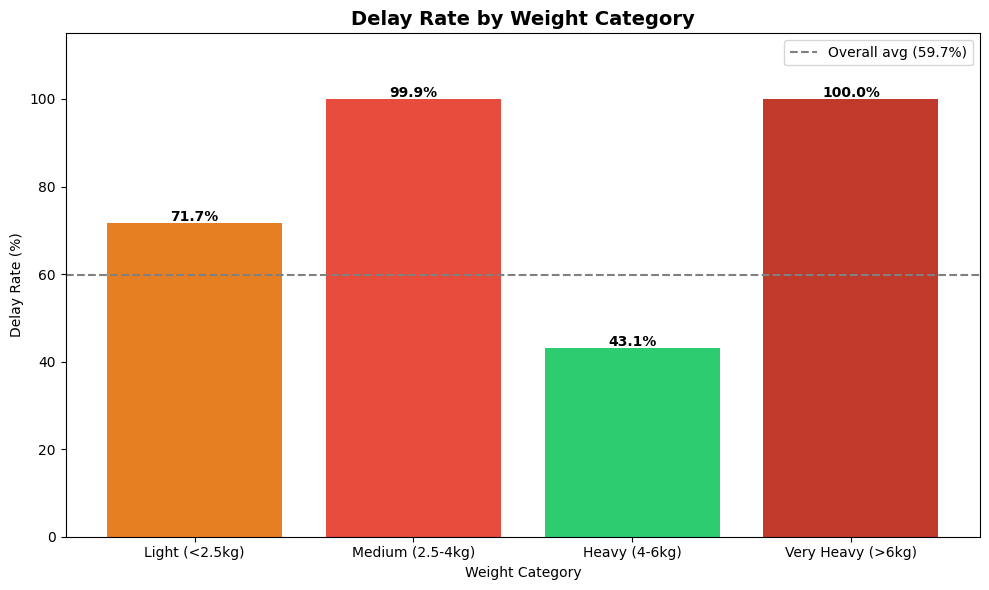

In [6]:
# Delay rate by weight category
df['weight_category'] = pd.cut(
    df['Weight_in_gms'],
    bins=[0, 2500, 4000, 6000, 8000],
    labels=['Light (<2.5kg)', 'Medium (2.5-4kg)', 'Heavy (4-6kg)', 'Very Heavy (>6kg)']
)

delay_by_weight = df.groupby('weight_category')['Reached.on.Time_Y.N'].mean() * 100

plt.figure(figsize=(10, 6))
bars = plt.bar(
    delay_by_weight.index,
    delay_by_weight.values,
    color=['#e67e22', '#e74c3c', '#2ecc71', '#c0392b']
)

for bar, val in zip(bars, delay_by_weight.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.axhline(y=59.7, color='gray', linestyle='--', label='Overall avg (59.7%)')
plt.title('Delay Rate by Weight Category', fontsize=14, fontweight='bold')
plt.xlabel('Weight Category')
plt.ylabel('Delay Rate (%)')
plt.ylim(0, 115)
plt.legend()
plt.tight_layout()
plt.savefig('delay_by_weight.png', dpi=150)
plt.show()

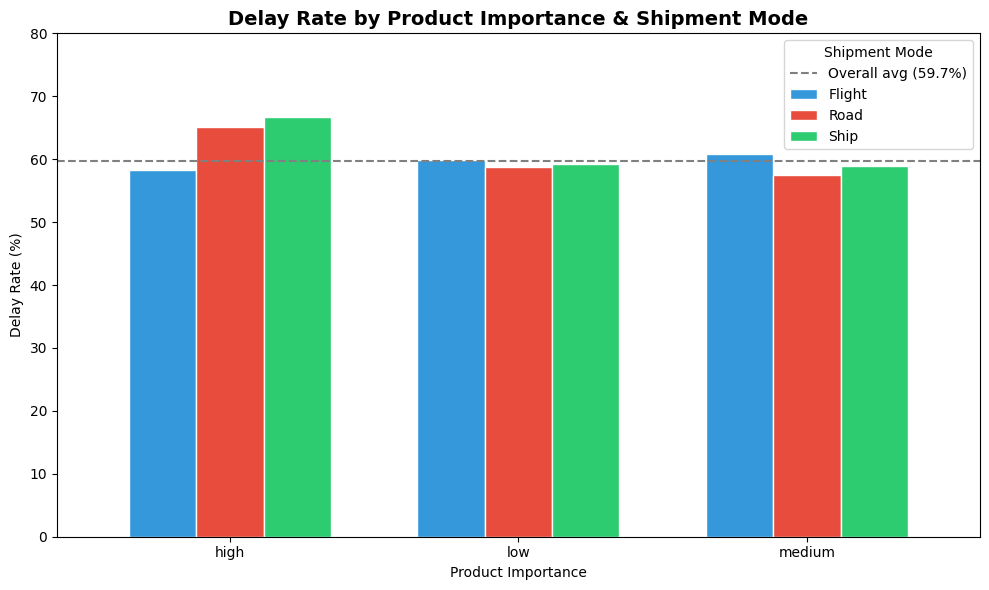

In [7]:
# Delay rate by Product Importance and Mode of Shipment
pivot = df.groupby(['Product_importance', 'Mode_of_Shipment'])['Reached.on.Time_Y.N'].mean() * 100
pivot = pivot.unstack()

plt.figure(figsize=(10, 6))
pivot.plot(kind='bar', ax=plt.gca(),
           color=['#3498db', '#e74c3c', '#2ecc71'],
           edgecolor='white', width=0.7)

plt.title('Delay Rate by Product Importance & Shipment Mode',
          fontsize=14, fontweight='bold')
plt.xlabel('Product Importance')
plt.ylabel('Delay Rate (%)')
plt.xticks(rotation=0)
plt.axhline(y=59.7, color='gray', linestyle='--', label='Overall avg (59.7%)')
plt.legend(title='Shipment Mode')
plt.ylim(0, 80)
plt.tight_layout()
plt.savefig('delay_importance_shipment.png', dpi=150)
plt.show()

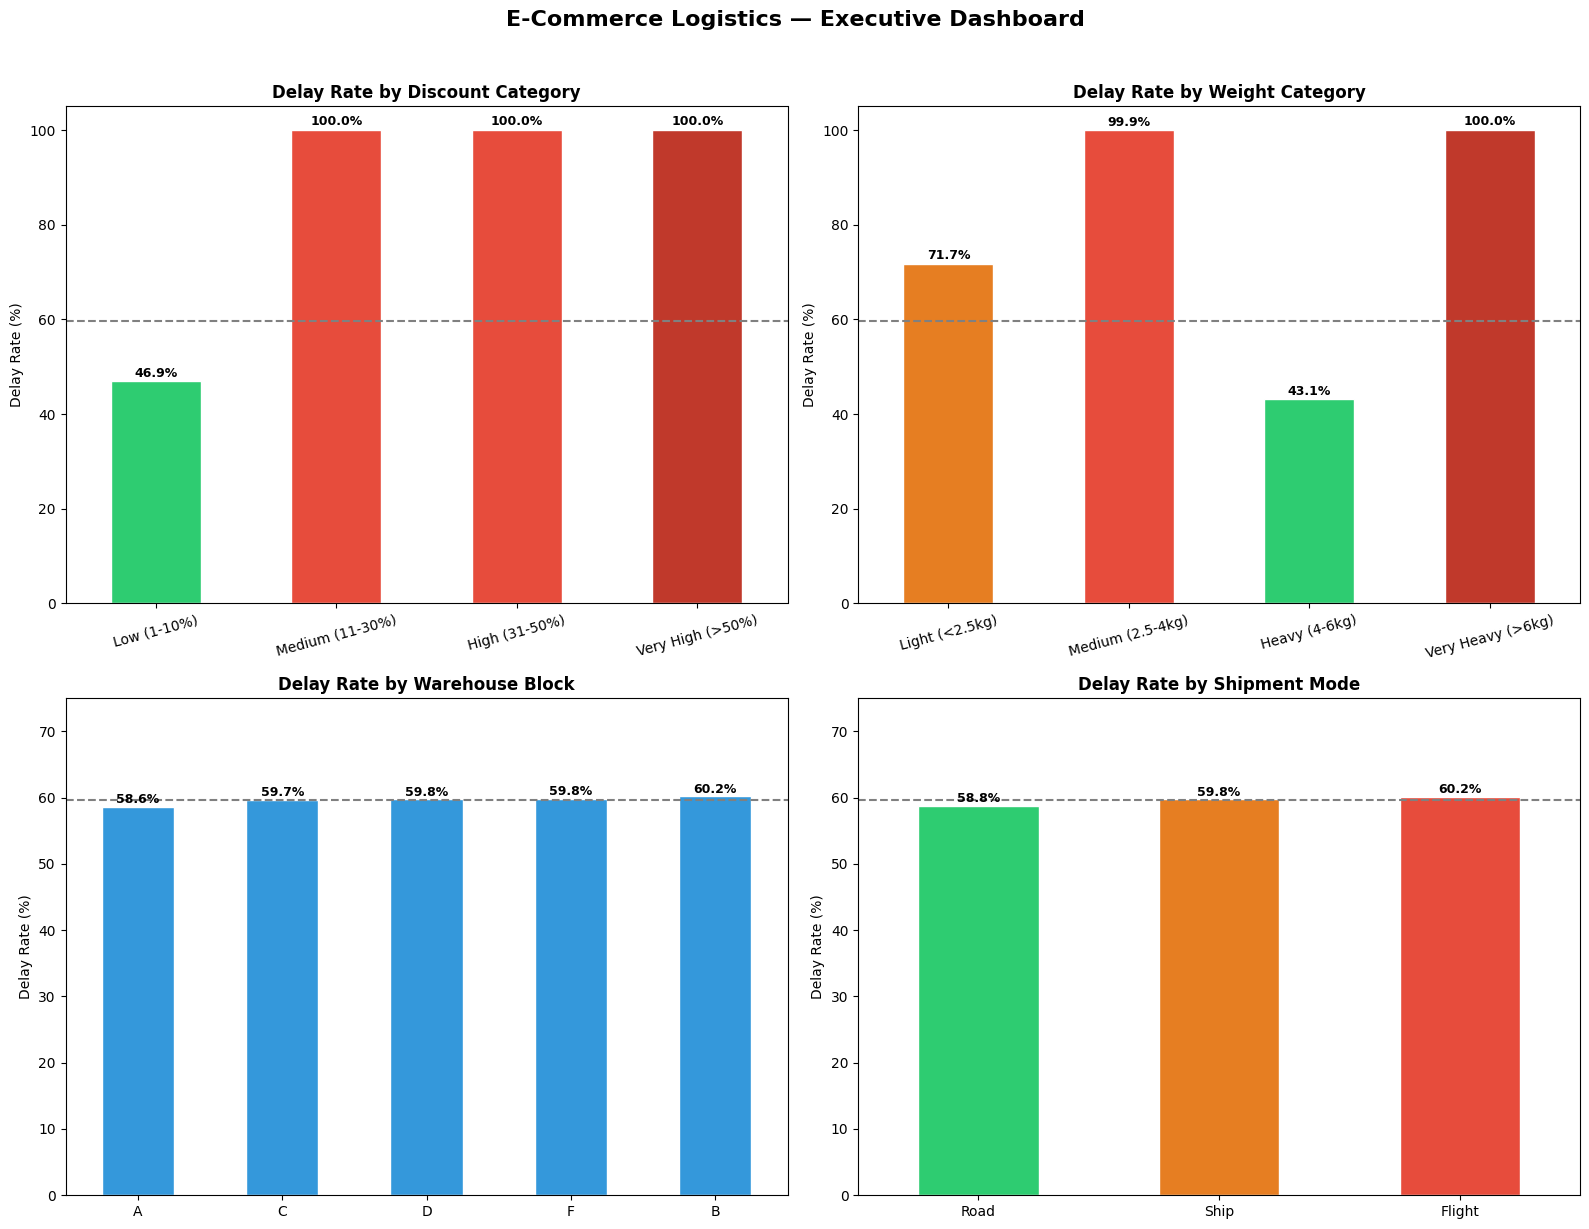

In [8]:
# Executive Dashboard — 4 panels
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('E-Commerce Logistics — Executive Dashboard',
             fontsize=16, fontweight='bold', y=1.02)

# Panel 1 — Delay by Discount
delay_by_discount.plot(kind='bar', ax=axes[0,0],
    color=['#2ecc71', '#e74c3c', '#e74c3c', '#c0392b'], edgecolor='white')
axes[0,0].set_title('Delay Rate by Discount Category', fontweight='bold')
axes[0,0].set_ylabel('Delay Rate (%)')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=15)
axes[0,0].axhline(y=59.7, color='gray', linestyle='--')
for bar, val in zip(axes[0,0].patches, delay_by_discount.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Panel 2 — Delay by Weight
delay_by_weight.plot(kind='bar', ax=axes[0,1],
    color=['#e67e22', '#e74c3c', '#2ecc71', '#c0392b'], edgecolor='white')
axes[0,1].set_title('Delay Rate by Weight Category', fontweight='bold')
axes[0,1].set_ylabel('Delay Rate (%)')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=15)
axes[0,1].axhline(y=59.7, color='gray', linestyle='--')
for bar, val in zip(axes[0,1].patches, delay_by_weight.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Panel 3 — Delay by Warehouse
warehouse_delay = df.groupby('Warehouse_block')['Reached.on.Time_Y.N'].mean() * 100
warehouse_delay.sort_values().plot(kind='bar', ax=axes[1,0],
    color='#3498db', edgecolor='white')
axes[1,0].set_title('Delay Rate by Warehouse Block', fontweight='bold')
axes[1,0].set_ylabel('Delay Rate (%)')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].axhline(y=59.7, color='gray', linestyle='--')
axes[1,0].set_ylim(0, 75)
for bar, val in zip(axes[1,0].patches, warehouse_delay.sort_values().values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Panel 4 — Delay by Shipment Mode
mode_delay = df.groupby('Mode_of_Shipment')['Reached.on.Time_Y.N'].mean() * 100
mode_delay.sort_values().plot(kind='bar', ax=axes[1,1],
    color=['#2ecc71', '#e67e22', '#e74c3c'], edgecolor='white')
axes[1,1].set_title('Delay Rate by Shipment Mode', fontweight='bold')
axes[1,1].set_ylabel('Delay Rate (%)')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].axhline(y=59.7, color='gray', linestyle='--')
axes[1,1].set_ylim(0, 75)
for bar, val in zip(axes[1,1].patches, mode_delay.sort_values().values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
!pip install fpdf2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 11.6 MB/s eta 0:00:00


In [11]:
from fpdf import FPDF
import pandas as pd

class LogisticsReport(FPDF):
    def header(self):
        self.set_font('Helvetica', 'B', 12)
        self.set_fill_color(30, 60, 114)
        self.set_text_color(255, 255, 255)
        self.cell(0, 12, 'E-Commerce Logistics - Executive Report',
                  fill=True, ln=True, align='C')
        self.ln(4)

    def footer(self):
        self.set_y(-15)
        self.set_font('Helvetica', 'I', 8)
        self.set_text_color(128, 128, 128)
        self.cell(0, 10, f'Page {self.page_no()} | Confidential', align='C')

pdf = LogisticsReport()
pdf.set_auto_page_break(auto=True, margin=15)

# ---- PAGE 1: OVERVIEW ----
pdf.add_page()
pdf.set_font('Helvetica', 'B', 20)
pdf.set_text_color(30, 60, 114)
pdf.ln(8)
pdf.cell(0, 12, 'Logistics Performance Analysis', ln=True, align='C')
pdf.set_font('Helvetica', '', 11)
pdf.set_text_color(100, 100, 100)
pdf.cell(0, 8, 'Dataset: E-Commerce Shipping Data | 10,999 records',
         ln=True, align='C')
pdf.ln(10)

kpis = [
    ('Total Shipments', '10,999'),
    ('Overall Delay Rate', '59.7%'),
    ('On-Time Rate', '40.3%'),
    ('Avg Customer Rating', '2.99 / 5.0'),
]

pdf.set_font('Helvetica', 'B', 12)
pdf.set_text_color(30, 60, 114)
pdf.cell(0, 8, 'Key Performance Indicators', ln=True)
pdf.ln(3)

pdf.set_font('Helvetica', '', 11)
for label, value in kpis:
    pdf.set_fill_color(240, 244, 255)
    pdf.set_text_color(50, 50, 50)
    pdf.cell(90, 10, f'  {label}', fill=True, border=1)
    pdf.set_fill_color(30, 60, 114)
    pdf.set_text_color(255, 255, 255)
    pdf.cell(100, 10, f'  {value}', fill=True, border=1, ln=True)
    pdf.ln(1)

pdf.ln(8)
pdf.set_font('Helvetica', 'B', 12)
pdf.set_text_color(30, 60, 114)
pdf.cell(0, 8, 'Executive Summary', ln=True)
pdf.set_font('Helvetica', '', 10)
pdf.set_text_color(50, 50, 50)
summary = """Analysis of 10,999 shipments reveals a systemic delivery performance issue
affecting 59.7% of all orders. The problem is not isolated to a specific warehouse
or shipment mode - all operational segments perform similarly. Two critical factors
were identified as primary drivers of delays: discount policy (orders with discounts
above 10% show 100% delay rate) and product weight range (2.5-4kg products show
99.9% delay rate). Immediate action on these two levers could significantly improve
on-time delivery performance."""
pdf.multi_cell(0, 6, summary)

# ---- PAGE 2: OPERATIONS PERSPECTIVE ----
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.set_text_color(30, 60, 114)
pdf.cell(0, 10, 'Operations Manager Perspective', ln=True)
pdf.set_draw_color(30, 60, 114)
pdf.set_line_width(0.5)
pdf.line(10, pdf.get_y(), 200, pdf.get_y())
pdf.ln(5)

findings_ops = [
    ('Finding 1 - Warehouse Performance',
     'All warehouse blocks (A-F) show similar delay rates between 58.6% and 60.2%. No single warehouse is responsible for the overall delay problem.'),
    ('Finding 2 - Shipment Mode',
     'Road (58.8%), Ship (59.8%), and Flight (60.2%) perform almost identically. Mode of shipment does not explain delays.'),
    ('Finding 3 - Weight Impact',
     'Products in the 2.5-4kg range show a 99.9% delay rate vs 43.1% for Heavy (4-6kg). The operation is optimized for high-volume weight ranges only.'),
    ('Finding 4 - Discount Policy',
     'Orders with discounts above 10% show 100% delay rate. Discount policy is the strongest predictor of delivery failure identified in this analysis.'),
]

for title, text in findings_ops:
    pdf.set_font('Helvetica', 'B', 11)
    pdf.set_text_color(30, 60, 114)
    pdf.cell(0, 8, title, ln=True)
    pdf.set_font('Helvetica', '', 10)
    pdf.set_text_color(50, 50, 50)
    pdf.multi_cell(0, 6, text)
    pdf.ln(3)

pdf.ln(3)
pdf.set_font('Helvetica', 'B', 11)
pdf.set_text_color(30, 60, 114)
pdf.cell(0, 8, 'Operations Dashboard', ln=True)
pdf.image('executive_dashboard.png', x=10, w=190)

# ---- PAGE 3: COMMERCIAL PERSPECTIVE ----
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.set_text_color(30, 60, 114)
pdf.cell(0, 10, 'Commercial Director Perspective', ln=True)
pdf.line(10, pdf.get_y(), 200, pdf.get_y())
pdf.ln(5)

findings_com = [
    ('Finding 5 - Customer Calls vs Satisfaction',
     'Average customer rating is 3.0 across all call volume segments. More calls do not improve satisfaction, but customers who call more experience fewer delays - suggesting informal prioritization.'),
    ('Finding 6 - Product Importance vs Delivery',
     'High importance products show the worst delay rate (64.98%). The importance flag is not being used operationally to prioritize shipments.'),
    ('Finding 7 - Customer Loyalty vs Service',
     'Frequent buyers (7+ purchases) experience 62.67% delay rate - nearly identical to new customers (63.46%). No loyalty-based service differentiation exists.'),
    ('Finding 8 - Warehouse Ranking',
     'Warehouse A ranks best overall (58.65% delay rate) while B ranks worst (60.23%). However, the difference is marginal and not statistically significant.'),
]

for title, text in findings_com:
    pdf.set_font('Helvetica', 'B', 11)
    pdf.set_text_color(30, 60, 114)
    pdf.cell(0, 8, title, ln=True)
    pdf.set_font('Helvetica', '', 10)
    pdf.set_text_color(50, 50, 50)
    pdf.multi_cell(0, 6, text)
    pdf.ln(3)

# ---- PAGE 4: RECOMMENDATIONS ----
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.set_text_color(30, 60, 114)
pdf.cell(0, 10, 'Strategic Recommendations', ln=True)
pdf.line(10, pdf.get_y(), 200, pdf.get_y())
pdf.ln(5)

recommendations = [
    ('IMMEDIATE', '1. Review discount policy - cap discounts at 10% or create operational capacity before offering higher discounts. Current policy guarantees delivery failure above this threshold.'),
    ('SHORT TERM', '2. Investigate 2.5-4kg weight range - identify packaging, handling, or routing issues specific to this segment. This range shows near-total delivery failure.'),
    ('SHORT TERM', '3. Integrate product importance flag into dispatch workflow - high importance products must trigger operational priority, not just commercial priority.'),
    ('MEDIUM TERM', '4. Implement customer loyalty service tiers - frequent buyers should receive measurable service advantages to reduce churn risk.'),
    ('MEDIUM TERM', '5. Deploy formal prioritization system - replace informal call-based prioritization with a rule-based system that protects all customers equally.'),
]

for priority, text in recommendations:
    if priority == 'IMMEDIATE':
        pdf.set_fill_color(231, 76, 60)
    elif priority == 'SHORT TERM':
        pdf.set_fill_color(230, 126, 34)
    else:
        pdf.set_fill_color(52, 152, 219)

    pdf.set_text_color(255, 255, 255)
    pdf.set_font('Helvetica', 'B', 9)
    pdf.cell(40, 8, f'  {priority}', fill=True, border=1)
    pdf.set_fill_color(245, 245, 245)
    pdf.set_text_color(50, 50, 50)
    pdf.set_font('Helvetica', '', 9)
    pdf.multi_cell(150, 8, f'  {text}', fill=True, border=1)
    pdf.ln(2)

pdf.ln(8)
pdf.set_font('Helvetica', 'I', 9)
pdf.set_text_color(100, 100, 100)
pdf.cell(0, 6, 'Report generated automatically with Python | Project: ecommerce-logistics-bi',
         ln=True, align='C')

pdf.output('executive_report.pdf')
print("Report generated successfully: executive_report.pdf")

/tmp/ipykernel_2158/927893035.py:9: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 12, 'E-Commerce Logistics - Executive Report',
/tmp/ipykernel_2158/927893035.py:27: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 12, 'Logistics Performance Analysis', ln=True, align='C')
/tmp/ipykernel_2158/927893035.py:30: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, 'Dataset: E-Commerce Shipping Data | 10,999 records',
/tmp/ipykernel_2158/927893035.py:43: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, 'Key Performance Indicators', ln=True)
/tmp/ipykernel_2158/927893035.py:53: DeprecationWarning: The parameter "ln" is depre

Report generated successfully: executive_report.pdf


/tmp/ipykernel_2158/927893035.py:111: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, 'Commercial Director Perspective', ln=True)
/tmp/ipykernel_2158/927893035.py:129: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, title, ln=True)
/tmp/ipykernel_2158/927893035.py:139: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, 'Strategic Recommendations', ln=True)
/tmp/ipykernel_2158/927893035.py:171: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 6, 'Report generated automatically with Python | Project: ecommerce-logistics-bi',
